# Parcial 2 – SVM, ANN y PCA 

## Enunciado

Tomamos un dataset del [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets) y debemos:

1. Entrenar una SVM con validación cruzada, probando distintos *kernels* y parámetros del kernel.
2. Entrenar una red neuronal feedforward (ANN) con validación cruzada, probando distintas arquitecturas (capas/neuronas) y funciones de activación.
3. Tomar las mejores configuraciones de SVM y ANN, aplicar PCA y repetir las pruebas. Concluir.

## Dataset escogido: *Breast Cancer Wisconsin (Diagnostic)*

Escojo este dataset porque:

- Tiene 569 instancias y 30 atributos numéricos, todos continuos: no requiere codificación de variables categóricas.
- Es una clasificación binaria (maligno vs benigno ), lo que facilita interpretar matrices de confusión.
- Tiene dimensionalidad alta (30 features), lo que hace que PCA tenga un papel real.

## Librerías 

- sklearn.svm.SVC para la SVM (con varios kernels).
- sklearn.neural_network.MLPClassifier para la red neuronal feedforward.
- sklearn.model_selection.GridSearchCV con StratifiedKFold para la validación cruzada y la búsqueda de hiperparámetros.
- sklearn.decomposition.PCA para la reducción de dimensionalidad.
- sklearn.preprocessing.StandardScaler  para estandarizar 

## 1. Imports y carga del dataset

Se carga el dataset y se revisa sus dimensiones, balance de clases y nombres de los atributos. Esto nos ayuda a entender qué estamos clasificando antes de interactuar con los modelos.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Nombres de las clases: {list(target_names)}")
print(f"Distribución de clases:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {target_names[cls]} (label={cls}): {cnt} muestras ({cnt/len(y)*100:.1f}%)")
print(f"\nPrimeras 5 features: {list(feature_names[:5])}")

Forma de X: (569, 30)
Forma de y: (569,)
Nombres de las clases: ['malignant', 'benign']
Distribución de clases:
  malignant (label=0): 212 muestras (37.3%)
  benign (label=1): 357 muestras (62.7%)

Primeras 5 features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']


### 1.1 Análisis exploratorio rápido

Hacemos un Análisis exploratorio de datos mínimo para confirmar:

1. Que el dataset esté razonablemente balanceado (importante para usar accuracy como métrica).
2. Que las features tienen escalas muy distintas entre sí, lo que justifica StandardScaler antes de SVM, ANN y PCA.

Estadísticas resumidas (primeras 6 features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104
std,3.524,4.301,24.299,351.914,0.014,0.053
min,6.981,9.710,43.790,143.500,0.053,0.019
25%,11.700,16.170,75.170,420.300,0.086,0.065
50%,13.370,18.840,86.240,551.100,0.096,0.093
75%,15.780,21.800,104.100,782.700,0.105,0.130
max,28.110,39.280,188.500,2501.000,0.163,0.345


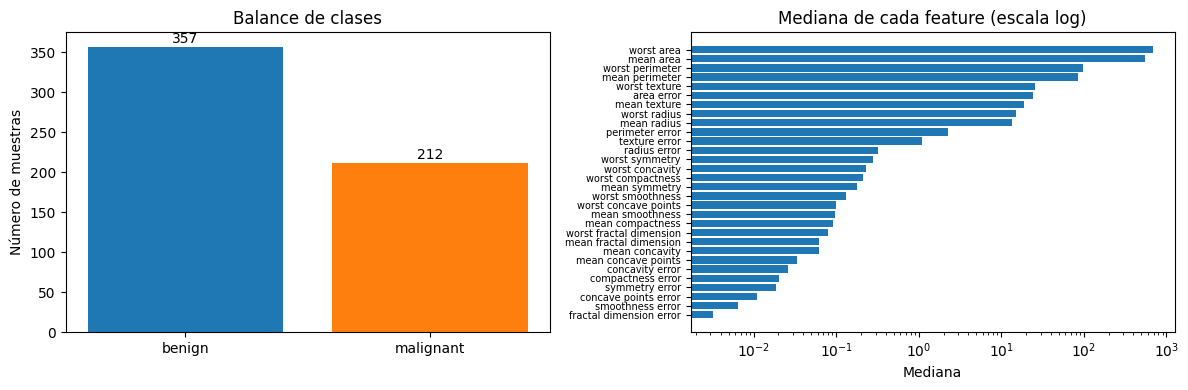

In [64]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["clase"] = df["target"].map({i: name for i, name in enumerate(target_names)})

print("Estadísticas resumidas (primeras 6 features):")
display(df.iloc[:, :6].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
counts = df["clase"].value_counts()
ax.bar(counts.index, counts.values, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Balance de clases")
ax.set_ylabel("Número de muestras")
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center")

ax = axes[1]
medians = df.iloc[:, :30].median().sort_values()
ax.barh(range(len(medians)), medians.values)
ax.set_yticks(range(len(medians)))
ax.set_yticklabels(medians.index, fontsize=7)
ax.set_xscale("log")
ax.set_title("Mediana de cada feature (escala log)")
ax.set_xlabel("Mediana")

plt.tight_layout()
plt.show()

Observaciones del EDA:

- El dataset tiene 569 muestras y está moderadamente desbalanceado: 357 benignos y 212 malignos. No es un desbalance extremo, pero sí suficiente para preferir una validación cruzada estratificada, de modo que cada fold conserve aproximadamente la misma proporción de clases.
- Las variables numéricas están en escalas muy diferentes. Por ejemplo, mean smoothness toma valores cercanos a 0.05, mientras que mean area y worst area están en el orden de cientos o miles. Esto implica que:
  - SVM con kernel RBF puede verse afectada por variables de gran magnitud si no se estandariza
  - La ANN puede tardar más en converger y entrenarse de forma inestable.
  - PCA quedaría dominado por las variables con mayor varianza absoluta, no necesariamente por las más informativas.
- Por estas razones, antes de entrenar SVM, ANN y PCA es necesario aplicar estandarización con StandardScaler dentro de un pipeline, para evitar fuga de información (data leakage) entre folds.

## 2. Preprocesamiento

Primero separamos un conjunto de prueba que se reserva hasta el final y no participa en la búsqueda de hiperparámetros. La selección de parámetros se hace solo con el conjunto de entrenamiento, usando GridSearchCV y StratifiedKFold para mantener la proporción de clases en cada fold. Cuando ya tenemos la mejor configuración, evaluamos ese modelo una sola vez sobre el conjunto de prueba para obtener una estimación más realista de su desempeño.

In [46]:
# stratify=y: hace que la proporción de clases se conserve en ambas partes. 
# la división siempre sea igual
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}, distribución: {np.bincount(y_train)}")
print(f"Test : {X_test.shape}, distribución: {np.bincount(y_test)}")

# shuffle: mezcla los datos antes de partirlos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"\nValidación cruzada: StratifiedKFold con k={cv.get_n_splits()} folds")

Train: (455, 30), distribución: [170 285]
Test : (114, 30), distribución: [42 72]

Validación cruzada: StratifiedKFold con k=5 folds


## 3. Punto 1. SVM con validación cruzada y diferentes kernels

### 3.1 Qué es una SVM

Una Máquina de Vectores de Soporte (SVM) busca el hiperplano que maximiza el margen entre las dos clases. Cuando los datos no son linealmente separables, usamos el truco del kernel: reemplazamos productos internos $\mathbf{a}^\top\mathbf{b}$ por una función $K(\mathbf{a},\mathbf{b})$ que corresponde a un producto interno en un espacio de mayor dimensión. Vamos a probar:

- linear: $K(\mathbf{a},\mathbf{b})=\mathbf{a}^\top\mathbf{b}$. Útil cuando los datos son aproximadamente separables linealmente.

- rbf (gaussiano):

$$
K(\mathbf{a},\mathbf{b})=\exp\left(-\frac{\|\mathbf{a}-\mathbf{b}\|^2}{2\sigma^2}\right).
$$

Equivalente a la parametrización con $\gamma$ empleada por scikit-learn: 

$$
K(\mathbf{a},\mathbf{b})=\exp(-\gamma\|\mathbf{a}-\mathbf{b}\|^2)
$$

con $\displaystyle\gamma=\frac{1}{2\sigma^2}$. Mide similitud por distancia: toma valores cercanos a 1 si $\mathbf{a}$ y $\mathbf{b}$ están próximos y decae exponencialmente cuando se alejan.

- poly: 

$$
K(\mathbf{a},\mathbf{b})=(\gamma\,\mathbf{a}^\top\mathbf{b}+r)^d.
$$

Captura interacciones polinómicas de grado $d$ (equivale a ingresar en un espacio de características con monomios hasta grado $d$).

- sigmoid: 

$$
K(\mathbf{a},\mathbf{b})=\tanh(\gamma\,\mathbf{a}^\top\mathbf{b}+r).
$$

Inspirado en redes neuronales; su comportamiento como kernel positivo semidefinido depende de los parámetros y por eso se usa con precaución.

### Referencias 

- scikit-learn — SVM (documentación): https://scikit-learn.org/stable/modules/svm.html
- Bishop, C. M., *Pattern Recognition and Machine Learning* (2006). Capítulo sobre kernels y RBF.
- Schölkopf, B. & Smola, A. J., *Learning with Kernels* (2002). Cambridge University Press.
- Cristianini, N. & Shawe-Taylor, J., *An Introduction to Support Vector Machines* (2000).
- Mercer's theorem (explicación): https://en.wikipedia.org/wiki/Mercer%27s_theorem
- Nota práctica sobre gamma/scale en scikit-learn: https://scikit-learn.org/stable/modules/svm.html#tips-on-practical-use

### 3.2 Búsqueda de hiperparámetros con GridSearchCV

Usamos un Pipeline que estandariza dentro de cada fold (evita data leakage) y luego entrena la SVM. La búsqueda se hace con GridSearchCV en el conjunto de entrenamiento, optimizando el f1_macro (más informativo que accuracy en datasets ligeramente desbalanceados).

In [47]:
# Crea un flujo que primero aplica StandardScaler y luego entrena SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=RANDOM_STATE)),
])

# se define las configuraciones a probar
# gamma = scale calcula automaticamente a partir de la varianza de los datos de entrenamiento
# se busca C y gamma en escala logarítmica
svm_param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale"],
    },
    {
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1],
    },
]

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

svm_grid.fit(X_train, y_train)

print(f"\nMejor combinación SVM: {svm_grid.best_params_}")
print(f"Mejor f1_macro (CV): {svm_grid.best_score_:.4f}")

Fitting 5 folds for each of 43 candidates, totalling 215 fits

Mejor combinación SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Mejor f1_macro (CV): 0.9739


### 3.3 Análisis de resultados de SVM

Vamos a examinar el desempeño promedio por kernel y a visualizar cómo se comporta cada uno cuando varían sus hiperparámetros principales.

In [48]:
svm_results = pd.DataFrame(svm_grid.cv_results_)
svm_results["kernel"] = svm_results["param_svm__kernel"]

#Ordenamos de mejor a peor, tomamos la mejor combinación por cada tipo de kernel
# Media del score en los folds:rendimiento promedio en validación cruzada
# Muestra desviación estándar del score entre folds, cuánto varía ese rendimiento entre folds — alto → resultados inestables.
# score promedio en el entrenamiento, si es mucho mayor que mean_test_score puede haber sobreajuste.
print("=== Mejor configuración por kernel ===")
best_per_kernel = (
    svm_results
    .sort_values("mean_test_score", ascending=False)
    .groupby("kernel")
    .head(1)[["kernel", "params", "mean_test_score", "std_test_score", "mean_train_score"]]
    .reset_index(drop=True)
)
display(best_per_kernel)

print("\n=== Top 10 configuraciones globales ===")
top10 = (
    svm_results
    .sort_values("mean_test_score", ascending=False)
    .head(10)[["params", "mean_test_score", "std_test_score"]]
    .reset_index(drop=True)
)
display(top10)

=== Mejor configuración por kernel ===


,kernel,params,mean_test_score,std_test_score,mean_train_score
0,rbf,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.973888,0.017677,0.988211
1,linear,"{'svm__C': 0.1, 'svm__kernel': 'linear'}",0.973853,0.011931,0.984662
2,sigmoid,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.968885,0.012363,0.971413
3,poly,"{'svm__C': 10, 'svm__degree': 3, 'svm__gamma':...",0.954004,0.026514,0.970783



=== Top 10 configuraciones globales ===


,params,mean_test_score,std_test_score
0,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.973888,0.017677
1,"{'svm__C': 0.1, 'svm__kernel': 'linear'}",0.973853,0.011931
2,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.969041,0.016283
3,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.969037,0.012363
4,"{'svm__C': 0.01, 'svm__kernel': 'linear'}",0.968885,0.012363
5,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.968885,0.012363
6,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.968758,0.022824
7,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.967086,0.013638
8,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.966940,0.015966
9,"{'svm__C': 100, 'svm__gamma': 'scale', 'svm__k...",0.964977,0.024332


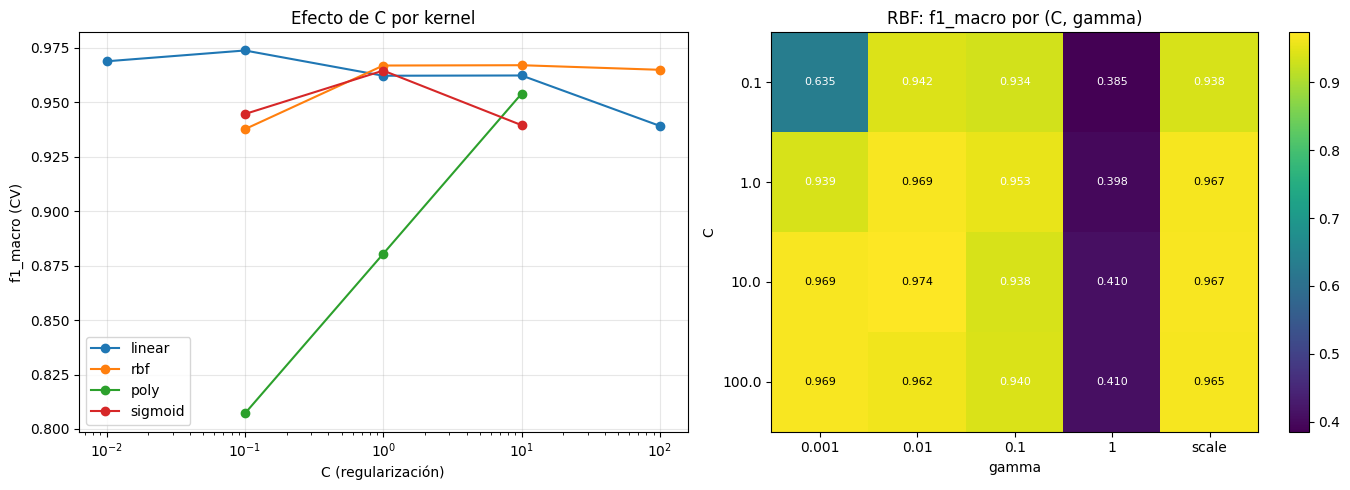

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    mask = svm_results["kernel"] == kernel
    sub = svm_results[mask].copy()
    if kernel == "rbf":
        sub = sub[sub["param_svm__gamma"] == "scale"]
    elif kernel == "poly":
        sub = sub[sub["param_svm__degree"] == 3]
    elif kernel == "sigmoid":
        sub = sub[sub["param_svm__gamma"] == "scale"]
    sub = sub.sort_values("param_svm__C")
    ax.plot(sub["param_svm__C"].astype(float), sub["mean_test_score"],
            marker="o", label=kernel)
ax.set_xscale("log")
ax.set_xlabel("C (regularización)")
ax.set_ylabel("f1_macro (CV)")
ax.set_title("Efecto de C por kernel")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
rbf_results = svm_results[svm_results["kernel"] == "rbf"].copy()
rbf_results["gamma_str"] = rbf_results["param_svm__gamma"].astype(str)
pivot = rbf_results.pivot_table(
    index="param_svm__C",
    columns="gamma_str",
    values="mean_test_score",
)
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("RBF: f1_macro por (C, gamma)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    color="white" if v < 0.96 else "black", fontsize=8)
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

### 3.4 Evaluación del mejor SVM en el conjunto de prueba

Tomamos el mejor estimador encontrado por GridSearchCV (que ya está reentrenado sobre todo X_train) y lo evaluamos en prueba. Reportamos accuracy, F1, matriz de confusión y el reporte por clase.

Mejor SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Accuracy en test: 0.9825
F1 macro en test: 0.9812

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



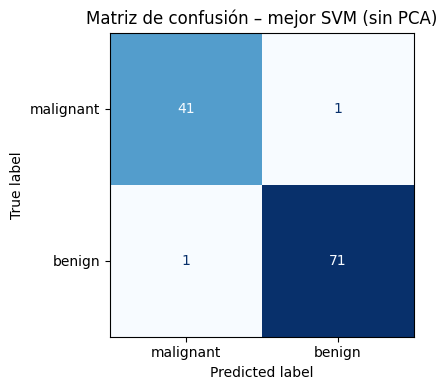

In [50]:
best_svm = svm_grid.best_estimator_ # Extrae el mejor modelo 
y_pred_svm = best_svm.predict(X_test) # Hacemos predicciones sonre el conjunto de prueba

acc_svm = accuracy_score(y_test, y_pred_svm) # Calculamos % de aciertos totales
f1_svm = f1_score(y_test, y_pred_svm, average="macro") # Media del f1 por clase
print(f"Mejor SVM: {svm_grid.best_params_}")
print(f"Accuracy en test: {acc_svm:.4f}")
print(f"F1 macro en test: {f1_svm:.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_svm, target_names=target_names))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión – mejor SVM (sin PCA)")
plt.tight_layout()
plt.show()

## 4. Punto 2. Red neuronal feedforward (MLP) con validación cruzada

### 4.1 Qué es una red neuronal — Perceptrón multicapa

Recordemos la función discriminante lineal con mapeo no lineal:

$$
d_i = \text{sign}\left(\boldsymbol{w}^T\phi(\boldsymbol{x}_i)\right)
$$

donde $\phi(\cdot)$ es una función que mapea las muestras $\boldsymbol{x}_i$ a un espacio de características de mayor dimensión. Una red neuronal feedforward (MLP, Multi-Layer Perceptron) define precisamente estas funciones base $\phi(\cdot)$ de forma métrica, apas de neuras conectadas hacia adelante.

a neurona individual calcula la sumatoria ponderada de sus entradas seguida de una función de activación derivable:

$$
\text{neurona}_j^{(\ell)} = \sigma_\ell\left(\boldsymbol{w}_{j,\ell}^T \boldsymbol{h}^{(\ell-1)} + b_{j,\ell}\right)
$$

donde:
- $\boldsymbol{w}_{j,\ell}$ es el vector de pesos de la neurona $j$ en la capa $\ell$
- $b_{j,\ell}$ es el sesgo (bias)
- $\boldsymbol{h}^{(\ell-1)}$ son las salidas de la capa anterior (o las entradas $\boldsymbol{x}$ si $\ell=1$)
- $\sigma_\ell$ es la función de activación de la capa $\ell$

Las funciones de activación más comunes (todas derivables para permitir backpropagation) son:

- tanh: $\sigma(z)=\tanh(z)$, con derivada $\frac{d\tanh(z)}{dz} = 1 - \tanh(z)^2$. Salida en $[-1,1]$, simétrica alrededor del 0. 
- logistic (sigmoide): $\sigma(z)=\frac{1}{1+e^{-z}}$, con derivada $\frac{d\sigma(z)}{dz} = \sigma(z)(1-\sigma(z))$. Salida en $[0,1]$.
- relu: $\sigma(z)=\max(0,z)$. Es más moderna y muy común en redes profundas; evita el problema de gradientes que se desvanecen, pero no tiene derivada en $z=0$.

La arquitectura multicapa conecta varias capas de neuronas. Por ejemplo, con 1 capa oculta:

$$
\boldsymbol{d} = \sigma_1\left(W_1 \boldsymbol{x} + \boldsymbol{b}_1\right) \quad \text{(capa oculta)}
$$
$$
\boldsymbol{s} = \sigma_2\left(W_2 \boldsymbol{d} + \boldsymbol{b}_2\right) \quad \text{(capa de salida)}
$$

Entrenamiento con backpropagation: El algoritmo de aprendizaje usa gradiente descendente estocástico:

$$
\boldsymbol{w}^{(\tau+1)} = \boldsymbol{w}^{(\tau)} - \alpha \nabla \varepsilon
$$

donde $\varepsilon = \frac{1}{2}\sum_k (s_k - y_k)^2$ es el error en mínimos cuadrados. El algoritmo backpropagation propaga el error hacia atrás a través de las capas, calculando derivadas parciales respecto a cada peso usando la regla de la cadena. Esto es posible gracias a que las funciones de activación son derivables.

Vamos a probar distintas arquitecturas:
- 1 capa oculta con 8, 16, 32, 64 neuronas.
- 2 capas ocultas: $(32,16)$, $(64,32)$, $(64,32,16)$ (3 capas totales).

### 4.2 Búsqueda de hiperparámetros con GridSearchCV

Igual que con SVM, usamos un Pipeline(StandardScaler → MLPClassifier). Esto es importante ya que los MLP son muy sensibles a la escala de las features, y sin estandarizar la convergencia es mala o no llega.

Configuramos el MLP con:
- solver="adam" (optimizador adaptativo, va bien para datasets de tamaño medio).
- early_stopping=True para detener si la validación interna deja de mejorar (evita sobreajuste).
- max_iter=500 suficiente para que converja.

In [51]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        solver="adam",
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )),
])

mlp_param_grid = {
    "mlp__hidden_layer_sizes": [
        (8,), (16,), (32,), (64,),
        (32, 16), (64, 32), (64, 32, 16),
    ],
    "mlp__activation": ["relu", "tanh", "logistic"],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
}

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

mlp_grid.fit(X_train, y_train)

print(f"\nMejor combinación MLP: {mlp_grid.best_params_}")
print(f"Mejor f1_macro (CV): {mlp_grid.best_score_:.4f}")

Fitting 5 folds for each of 63 candidates, totalling 315 fits

Mejor combinación MLP: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64, 32)}
Mejor f1_macro (CV): 0.9604


### 4.3 Análisis de resultados de la ANN

Comparamos cómo afecta cada hiperparámetro al desempeño promedio:

In [52]:
mlp_results = pd.DataFrame(mlp_grid.cv_results_)
mlp_results["arch"] = mlp_results["param_mlp__hidden_layer_sizes"].astype(str)
mlp_results["activation"] = mlp_results["param_mlp__activation"]
mlp_results["alpha"] = mlp_results["param_mlp__alpha"]

print("=== Mejor configuración por activación ===")
best_per_act = (
    mlp_results
    .sort_values("mean_test_score", ascending=False)
    .groupby("activation")
    .head(1)[["activation", "arch", "alpha", "mean_test_score", "std_test_score", "mean_train_score"]]
    .reset_index(drop=True)
)
display(best_per_act)

print("\n=== Top 10 configuraciones globales ===")
top10_mlp = (
    mlp_results
    .sort_values("mean_test_score", ascending=False)
    .head(10)[["arch", "activation", "alpha", "mean_test_score", "std_test_score"]]
    .reset_index(drop=True)
)
display(top10_mlp)

=== Mejor configuración por activación ===


,activation,arch,alpha,mean_test_score,std_test_score,mean_train_score
0,tanh,"(64, 32)",0.0100,0.960385,0.023993,0.966833
1,relu,"(32, 16)",0.0001,0.953645,0.012314,0.953057
2,logistic,"(64,)",0.0001,0.911144,0.027415,0.909711



=== Top 10 configuraciones globales ===


,arch,activation,alpha,mean_test_score,std_test_score
0,"(64, 32)",tanh,0.0100,0.960385,0.023993
1,"(64, 32)",tanh,0.0001,0.960385,0.023993
2,"(64, 32)",tanh,0.0010,0.960385,0.023993
3,"(32, 16)",relu,0.0001,0.953645,0.012314
4,"(32, 16)",relu,0.0100,0.953645,0.012314
5,"(32, 16)",relu,0.0010,0.953645,0.012314
6,"(64, 32, 16)",relu,0.0001,0.951941,0.029767
7,"(64, 32, 16)",relu,0.0100,0.951941,0.029767
8,"(64, 32, 16)",relu,0.0010,0.951941,0.029767
9,"(64, 32)",relu,0.0001,0.945663,0.024020


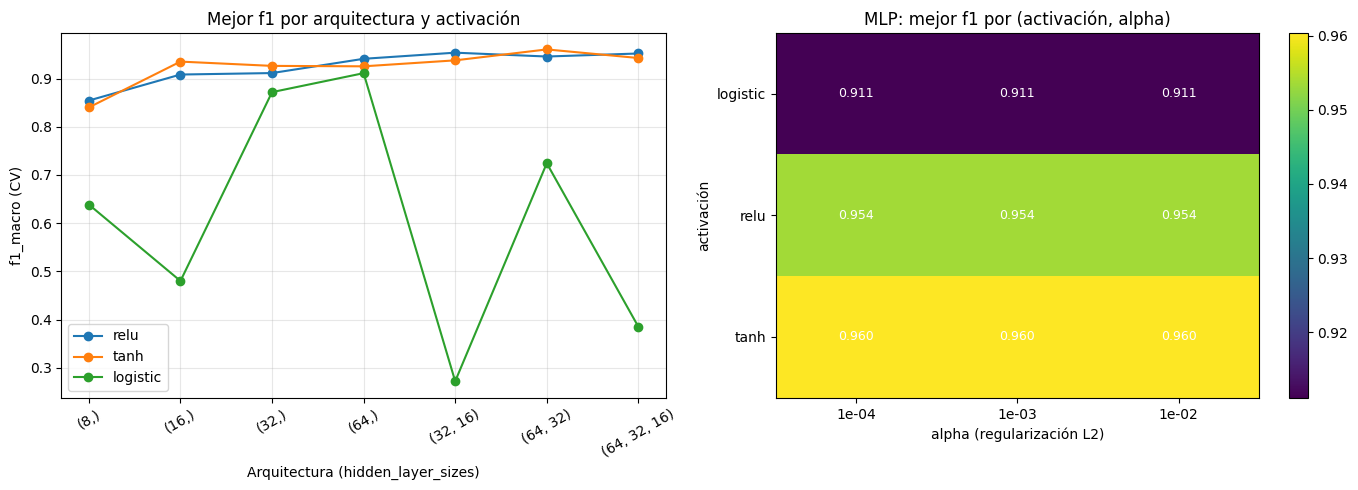

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
arch_order = ["(8,)", "(16,)", "(32,)", "(64,)", "(32, 16)", "(64, 32)", "(64, 32, 16)"]
for activation in ["relu", "tanh", "logistic"]:
    sub = mlp_results[mlp_results["activation"] == activation]
    sub = sub.groupby("arch")["mean_test_score"].max().reindex(arch_order)
    ax.plot(range(len(arch_order)), sub.values, marker="o", label=activation)
ax.set_xticks(range(len(arch_order)))
ax.set_xticklabels(arch_order, rotation=30)
ax.set_ylabel("f1_macro (CV)")
ax.set_xlabel("Arquitectura (hidden_layer_sizes)")
ax.set_title("Mejor f1 por arquitectura y activación")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
pivot_alpha = (
    mlp_results
    .groupby(["activation", "alpha"])["mean_test_score"]
    .max()
    .unstack("alpha")
)
im = ax.imshow(pivot_alpha.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(pivot_alpha.columns)))
ax.set_xticklabels([f"{a:.0e}" for a in pivot_alpha.columns])
ax.set_yticks(range(len(pivot_alpha.index)))
ax.set_yticklabels(pivot_alpha.index)
ax.set_xlabel("alpha (regularización L2)")
ax.set_ylabel("activación")
ax.set_title("MLP: mejor f1 por (activación, alpha)")
for i in range(pivot_alpha.shape[0]):
    for j in range(pivot_alpha.shape[1]):
        v = pivot_alpha.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    color="white" if v < 0.97 else "black", fontsize=9)
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

### 4.4 Evaluación del mejor MLP en el conjunto de prueba

Mejor MLP: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64, 32)}
Accuracy en test: 0.9561
F1 macro en test: 0.9531

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



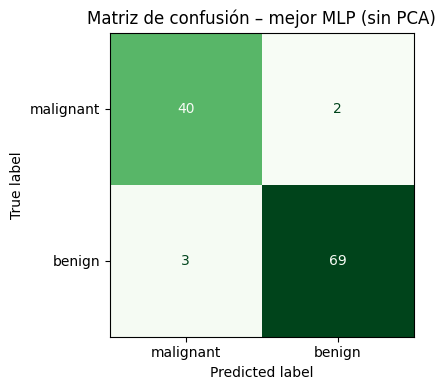

In [54]:
best_mlp = mlp_grid.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average="macro")
print(f"Mejor MLP: {mlp_grid.best_params_}")
print(f"Accuracy en test: {acc_mlp:.4f}")
print(f"F1 macro en test: {f1_mlp:.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_mlp, target_names=target_names))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matriz de confusión – mejor MLP (sin PCA)")
plt.tight_layout()
plt.show()

## 5. Punto 3. PCA y comparación con los mejores modelos

### 5.1 ¿Qué hace PCA y por qué tiene sentido aquí?

El Análisis de Componentes Principales (PCA) busca una transformación lineal ortogonal que proyecte los datos sobre un nuevo sistema de ejes (componentes principales) ordenados por la cantidad de varianza que capturan. Formalmente, si $X$ es la matriz centrada y $\Sigma=\tfrac{1}{n}X^\top X$ es su covarianza, los componentes principales son los vectores propios de $\Sigma$ ordenados por valor propio descendente.

PCA tiene sentido en este dataset porque:

- Tenemos 30 features, varias de las cuales son altamente correlacionadas (por ejemplo mean radius, mean perimeter y mean area miden esencialmente lo mismo).
- Reducir la dimensionalidad descorrelaciona las features y elimina ruido.
- Hace que los modelos sean más rápidos, a veces más estables y, en el caso del MLP, menos propensos a sobreajuste.
> PCA debe aplicarse después de estandarizar, porque es sensible a la escala. Lo metemos en un Pipeline para que la transformación se aprenda solo en cada fold de entrenamiento (sin leakage).

### 5.2 Análisis de varianza

Primero ajustamos PCA solo para ver cuántos componentes son razonables.

Componentes para >=95% de varianza: 10
Componentes para >=99% de varianza: 17
Varianza explicada por los primeros 5 PC: 85.14%


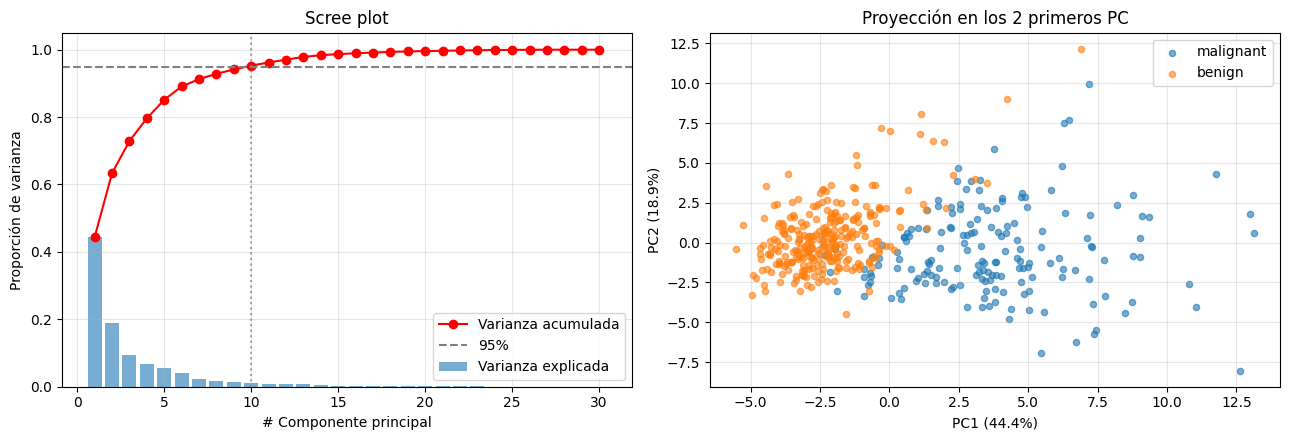

In [55]:
scaler_pca = StandardScaler().fit(X_train) #Estandarizamos xtrain y xtest
X_train_std = scaler_pca.transform(X_train)  
X_test_std = scaler_pca.transform(X_test)

pca_full = PCA(n_components=X_train_std.shape[1], random_state=RANDOM_STATE) 
pca_full.fit(X_train_std)

# explained_variance_ratio_ dice qué porcentaje de la información total captura cada componente.
cumvar = np.cumsum(pca_full.explained_variance_ratio_) 
n_for_95 = int(np.argmax(cumvar >= 0.95) + 1)
n_for_99 = int(np.argmax(cumvar >= 0.99) + 1)

print(f"Componentes para >=95% de varianza: {n_for_95}")
print(f"Componentes para >=99% de varianza: {n_for_99}")
print(f"Varianza explicada por los primeros 5 PC: {cumvar[4]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_,
       alpha=0.6, label="Varianza explicada")
ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", color="red",
        label="Varianza acumulada")
ax.axhline(0.95, color="grey", linestyle="--", label="95%")
ax.axvline(n_for_95, color="grey", linestyle=":", alpha=0.7)
ax.set_xlabel("# Componente principal")
ax.set_ylabel("Proporción de varianza")
ax.set_title("Scree plot")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
X_pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_train_std)
for cls in [0, 1]:
    mask = y_train == cls
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=target_names[cls], alpha=0.6, s=20)
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Proyección en los 2 primeros PC")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Vemos que con muy pocos componentes ya capturamos la mayor parte de la varianza. La proyección en 2D muestra que las clases ya son bastante separables solo con PC1 y PC2, lo que sugiere que el dataset tiene una estructura de baja dimensión intrínseca pese a tener 30 features.

### 5.3 Repetir SVM y MLP con las mejores configuraciones, ahora con PCA

Repetimos la búsqueda acotada a la mejor configuración previa (con un pequeño barrido de n_components) para ver cómo cambia el desempeño.

In [56]:
best_svm_params = {k.replace("svm__", ""): v for k, v in svm_grid.best_params_.items()}
best_mlp_params = {k.replace("mlp__", ""): v for k, v in mlp_grid.best_params_.items()}

print(f"Mejor SVM (sin PCA): {best_svm_params}")
print(f"Mejor MLP (sin PCA): {best_mlp_params}")

n_components_grid = [2, 5, 10, 15, n_for_95, n_for_99]
n_components_grid = sorted(set(n_components_grid))
print(f"\nComponentes a probar: {n_components_grid}")

Mejor SVM (sin PCA): {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor MLP (sin PCA): {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}

Componentes a probar: [2, 5, 10, 15, 17]


In [ ]:
def evaluate_with_pca(model_factory, n_components_list, X_tr, y_tr, X_te, y_te, cv):
    """Reentrena el modelo dado dentro de un Pipeline para varios valores de n_components, devolviendo CV-score y desempeño en test."""
    rows = []
    for n in n_components_list:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n, random_state=RANDOM_STATE)),
            ("model", model_factory()),
        ])
        cv_scores = cross_val_score(pipe, X_tr, y_tr, scoring="f1_macro", cv=cv, n_jobs=-1)
        pipe.fit(X_tr, y_tr)
        y_hat = pipe.predict(X_te)
        rows.append({
            "n_components": n,
            "cv_f1_mean": cv_scores.mean(),
            "cv_f1_std": cv_scores.std(),
            "test_acc": accuracy_score(y_te, y_hat),
            "test_f1": f1_score(y_te, y_hat, average="macro"),
        })
    return pd.DataFrame(rows), pipe

svm_factory = lambda: SVC(random_state=RANDOM_STATE, best_svm_params)
mlp_factory = lambda: MLPClassifier(
    solver="adam", max_iter=500, early_stopping=True,
    random_state=RANDOM_STATE, best_mlp_params,
)

print("Evaluando SVM con PCA...")
svm_pca_results, _ = evaluate_with_pca(
    svm_factory, n_components_grid, X_train, y_train, X_test, y_test, cv,
)
display(svm_pca_results.round(4))

print("\nEvaluando MLP con PCA...")
mlp_pca_results, _ = evaluate_with_pca(
    mlp_factory, n_components_grid, X_train, y_train, X_test, y_test, cv,
)
display(mlp_pca_results.round(4))

Evaluando SVM con PCA...


,n_components,cv_f1_mean,cv_f1_std,test_acc,test_f1
0,2,0.9339,0.0328,0.9298,0.9246
1,5,0.9789,0.0115,0.9561,0.9535
2,10,0.9762,0.0133,0.9561,0.9535
3,15,0.9763,0.0131,0.9825,0.9812
4,17,0.9763,0.0131,0.9825,0.9812



Evaluando MLP con PCA...


,n_components,cv_f1_mean,cv_f1_std,test_acc,test_f1
0,2,0.9378,0.0365,0.9474,0.9422
1,5,0.9550,0.0350,0.9474,0.9429
2,10,0.9484,0.0189,0.9035,0.8994
3,15,0.9644,0.0199,0.9649,0.9623
4,17,0.9398,0.0299,0.9649,0.9619


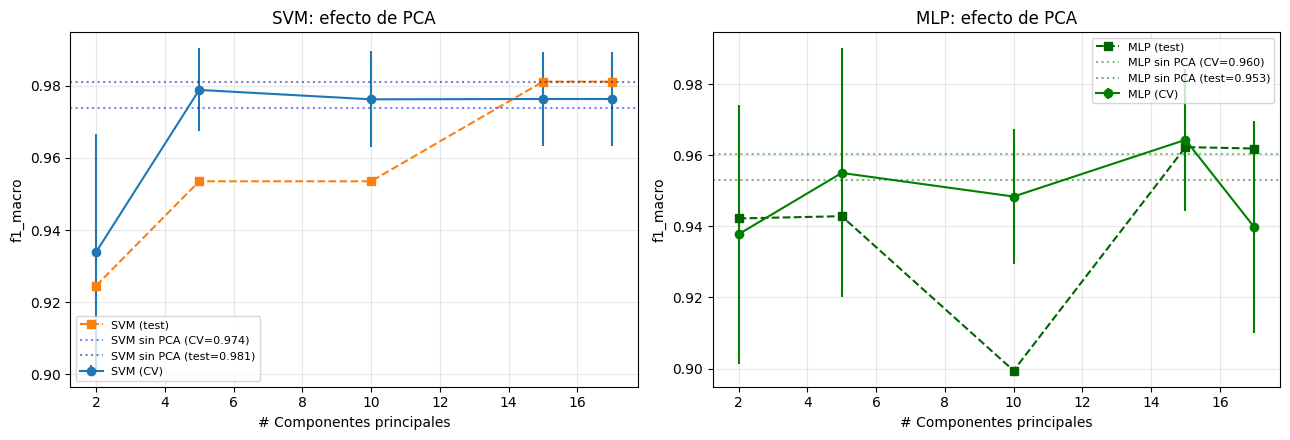

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.errorbar(svm_pca_results["n_components"], svm_pca_results["cv_f1_mean"],
            yerr=svm_pca_results["cv_f1_std"], marker="o", label="SVM (CV)")
ax.plot(svm_pca_results["n_components"], svm_pca_results["test_f1"],
        marker="s", linestyle="--", label="SVM (test)")
ax.axhline(svm_grid.best_score_, color="blue", linestyle=":", alpha=0.5,
           label=f"SVM sin PCA (CV={svm_grid.best_score_:.3f})")
ax.axhline(f1_svm, color="navy", linestyle=":", alpha=0.5,
           label=f"SVM sin PCA (test={f1_svm:.3f})")
ax.set_xlabel("# Componentes principales")
ax.set_ylabel("f1_macro")
ax.set_title("SVM: efecto de PCA")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.errorbar(mlp_pca_results["n_components"], mlp_pca_results["cv_f1_mean"],
            yerr=mlp_pca_results["cv_f1_std"], marker="o", color="green", label="MLP (CV)")
ax.plot(mlp_pca_results["n_components"], mlp_pca_results["test_f1"],
        marker="s", linestyle="--", color="darkgreen", label="MLP (test)")
ax.axhline(mlp_grid.best_score_, color="green", linestyle=":", alpha=0.5,
           label=f"MLP sin PCA (CV={mlp_grid.best_score_:.3f})")
ax.axhline(f1_mlp, color="darkgreen", linestyle=":", alpha=0.5,
           label=f"MLP sin PCA (test={f1_mlp:.3f})")
ax.set_xlabel("# Componentes principales")
ax.set_ylabel("f1_macro")
ax.set_title("MLP: efecto de PCA")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Mejor modelo combinado (SVM/MLP con su mejor n_components)

Tomamos el mejor n_components para cada modelo (según la métrica de CV) y miramos su matriz de confusión final.

Mejor n_components para SVM: 5
Mejor n_components para MLP: 15

--- SVM con PCA ---
Accuracy: 0.9561
F1 macro: 0.9535

--- MLP con PCA ---
Accuracy: 0.9649
F1 macro: 0.9623


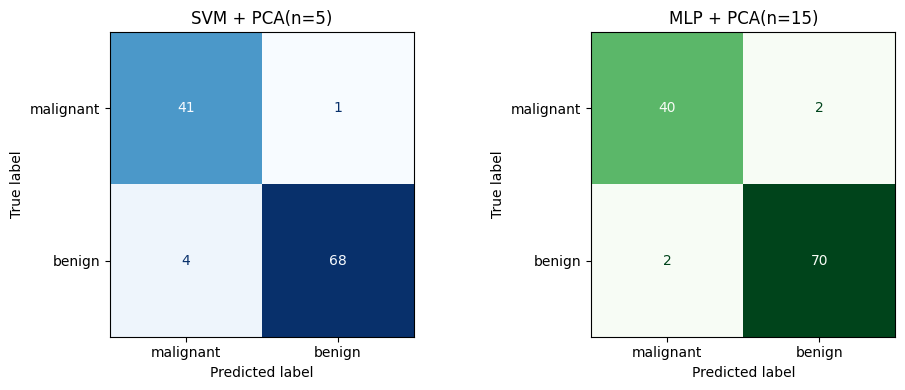

In [ ]:
best_n_svm = int(svm_pca_results.loc[svm_pca_results["cv_f1_mean"].idxmax(), "n_components"])
best_n_mlp = int(mlp_pca_results.loc[mlp_pca_results["cv_f1_mean"].idxmax(), "n_components"])
print(f"Mejor n_components para SVM: {best_n_svm}")
print(f"Mejor n_components para MLP: {best_n_mlp}")

best_svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_n_svm, random_state=RANDOM_STATE)),
    ("svm", SVC(random_state=RANDOM_STATE, best_svm_params)),
]).fit(X_train, y_train)

best_mlp_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_n_mlp, random_state=RANDOM_STATE)),
    ("mlp", MLPClassifier(
        solver="adam", max_iter=500, early_stopping=True,
        random_state=RANDOM_STATE, best_mlp_params,
    )),
]).fit(X_train, y_train)

y_pred_svm_pca = best_svm_pca.predict(X_test)
y_pred_mlp_pca = best_mlp_pca.predict(X_test)

print("\n--- SVM con PCA ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_pca):.4f}")
print(f"F1 macro: {f1_score(y_test, y_pred_svm_pca, average='macro'):.4f}")

print("\n--- MLP con PCA ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp_pca):.4f}")
print(f"F1 macro: {f1_score(y_test, y_pred_mlp_pca, average='macro'):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_svm_pca, f"SVM + PCA(n={best_n_svm})", "Blues"),
    (axes[1], y_pred_mlp_pca, f"MLP + PCA(n={best_n_mlp})", "Greens"),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 5.5 PUNTO SUSTENTACIÓN (3)
3) En el punto 3 del parcial se aplica PCA y se comparan resultados. Modifique el experimento considerando:

• Variar el número de componentes principales retenidas (por ejemplo: 50%, 70%, 90%, 100% de varianza explicada).

• Comparar el desempeño de SVM y ANN en funciÓn de esta reducciÓn dimensional.
Explique:

• ¿Por qué PCA puede mejorar el desempeñoo en algunos casos y empeorarlo en otros?

• ¿Cuál de los algoritmos se ve más afectado por el porcentaje de varianza acumulado y a qué se deberá?

Para responder al Punto 3 del enunciado, repetimos la evaluación de SVM y MLP escogiendo n_components por umbrales de varianza acumulada: 50%, 70%, 90% y 100%. Así la decisión se basa en una propiedad intrínseca del dataset (cuánta información retenemos) en vez de a un valor arbitrario.

Para cada umbral usamos los mejores hiperparámetros ya hallados y analizamos f1_macro en CV (con desviación entre folds) y en el conjunto de prueba.

Mapeo umbral de varianza → n_components:
   50.0%  →  n_components =  2   (varianza real: 63.36%)
   70.0%  →  n_components =  3   (varianza real: 72.90%)
   90.0%  →  n_components =  7   (varianza real: 91.26%)
  100.0%  →  n_components = 30   (varianza real: 100.00%)

Evaluando SVM por umbral de varianza...
Evaluando MLP por umbral de varianza...

=== SVM por % de varianza retenida ===


,var_target,n_components,cv_f1_mean,cv_f1_std,test_acc,test_f1
0,50%,2,0.9339,0.0328,0.9298,0.9246
1,70%,3,0.9457,0.0241,0.9474,0.9435
2,90%,7,0.9716,0.0096,0.9474,0.9440
3,100%,30,0.9739,0.0177,0.9825,0.9812


=== MLP por % de varianza retenida ===


,var_target,n_components,cv_f1_mean,cv_f1_std,test_acc,test_f1
0,50%,2,0.9378,0.0365,0.9474,0.9422
1,70%,3,0.9218,0.0122,0.9035,0.8978
2,90%,7,0.9378,0.0187,0.9474,0.9435
3,100%,30,0.9513,0.0113,0.9649,0.9627


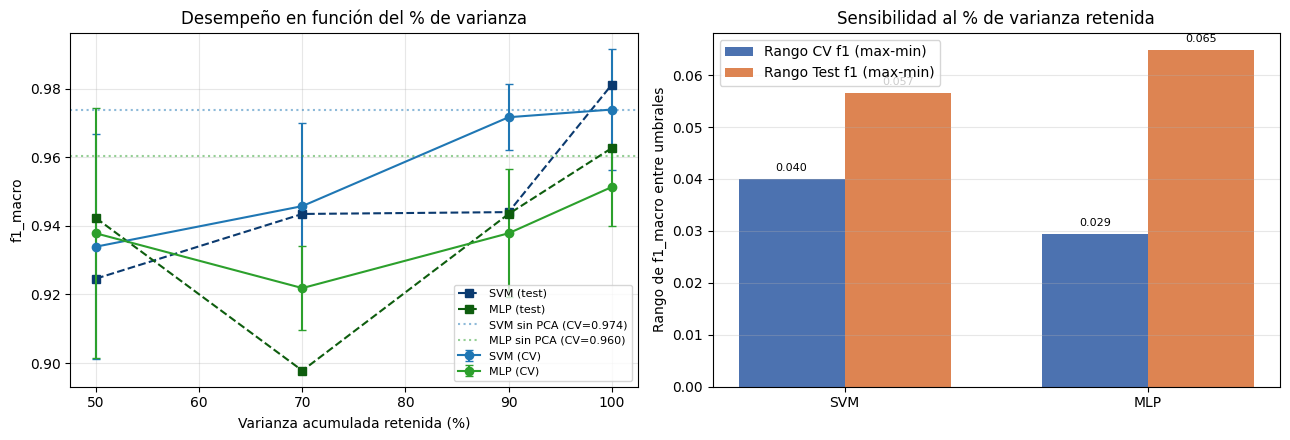

In [60]:
variance_targets = [0.50, 0.70, 0.90, 1.00]
n_for_targets = []
for v in variance_targets:
    if v >= 0.9999:
        n = X_train.shape[1]
    else:
        n = int(np.argmax(cumvar >= v) + 1)
    n_for_targets.append(n)

print("Mapeo umbral de varianza → n_components:")
for v, n in zip(variance_targets, n_for_targets):
    print(f"  {v*100:>5.1f}%  →  n_components = {n:>2d}   (varianza real: {cumvar[n-1]*100:.2f}%)")

print("\nEvaluando SVM por umbral de varianza...")
svm_var_results, _ = evaluate_with_pca(
    svm_factory, n_for_targets, X_train, y_train, X_test, y_test, cv,
)
svm_var_results.insert(0, "var_target", [f"{v*100:.0f}%" for v in variance_targets])

print("Evaluando MLP por umbral de varianza...")
mlp_var_results, _ = evaluate_with_pca(
    mlp_factory, n_for_targets, X_train, y_train, X_test, y_test, cv,
)
mlp_var_results.insert(0, "var_target", [f"{v*100:.0f}%" for v in variance_targets])

print("\n=== SVM por % de varianza retenida ===")
display(svm_var_results.round(4))
print("=== MLP por % de varianza retenida ===")
display(mlp_var_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
xs = [v * 100 for v in variance_targets]
ax.errorbar(xs, svm_var_results["cv_f1_mean"], yerr=svm_var_results["cv_f1_std"],
            marker="o", capsize=3, color="#1f77b4", label="SVM (CV)")
ax.plot(xs, svm_var_results["test_f1"], marker="s", linestyle="--",
        color="#0b3a6f", label="SVM (test)")
ax.errorbar(xs, mlp_var_results["cv_f1_mean"], yerr=mlp_var_results["cv_f1_std"],
            marker="o", capsize=3, color="#2ca02c", label="MLP (CV)")
ax.plot(xs, mlp_var_results["test_f1"], marker="s", linestyle="--",
        color="#0e5d0e", label="MLP (test)")
ax.axhline(svm_grid.best_score_, color="#1f77b4", linestyle=":", alpha=0.5,
           label=f"SVM sin PCA (CV={svm_grid.best_score_:.3f})")
ax.axhline(mlp_grid.best_score_, color="#2ca02c", linestyle=":", alpha=0.5,
           label=f"MLP sin PCA (CV={mlp_grid.best_score_:.3f})")
ax.set_xlabel("Varianza acumulada retenida (%)")
ax.set_ylabel("f1_macro")
ax.set_title("Desempeño en función del % de varianza")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

ax = axes[1]
modelos_lbl = ["SVM", "MLP"]
range_cv = [svm_var_results["cv_f1_mean"].max() - svm_var_results["cv_f1_mean"].min(),
            mlp_var_results["cv_f1_mean"].max() - mlp_var_results["cv_f1_mean"].min()]
range_test = [svm_var_results["test_f1"].max() - svm_var_results["test_f1"].min(),
              mlp_var_results["test_f1"].max() - mlp_var_results["test_f1"].min()]
xs2 = np.arange(len(modelos_lbl))
w = 0.35
ax.bar(xs2 - w/2, range_cv, w, color="#4c72b0", label="Rango CV f1 (max-min)")
ax.bar(xs2 + w/2, range_test, w, color="#dd8452", label="Rango Test f1 (max-min)")
for i, (rc, rt) in enumerate(zip(range_cv, range_test)):
    ax.text(i - w/2, rc + 0.0015, f"{rc:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, rt + 0.0015, f"{rt:.3f}", ha="center", fontsize=8)
ax.set_xticks(xs2)
ax.set_xticklabels(modelos_lbl)
ax.set_ylabel("Rango de f1_macro entre umbrales")
ax.set_title("Sensibilidad al % de varianza retenida")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Discusión

#### ¿Por qué PCA puede mejorar el desempeño en algunos casos y empeorarlo en otros?

Podríamos decir que PCA es un método no supervisado ya que rota los ejes para alinearlos con las direcciones de mayor varianza, pero no mira las etiquetas. Esto produce dos efectos opuestos según el dataset y el modelo:

Casos en que PCA mejora:

- Cuando las direcciones de baja varianza son ruido (variables redundantes, mediciones imprecisas o features muy correlacionadas). En este caso  descartarlas limpia la representación y reduce overfitting.
- Cuando el modelo es flexible pues menos features significa menos parámetros entrenables o sea una regularización implícita.
- Cuando el modelo depende fuertemente de la dimensionalidad. Por ejemplo el kernel RBF se ve beneficiado por un espacio más compacto y mejor condicionado.

Casos en que PCA empeora:

- Cuando la información discriminante está en direcciones de baja varianza. PCA las descarta y con ellas, la información importante que separa las clases. PCA optimiza por varianza, no por separabilidad.
- Cuando recortamos demasiado, con 50% de varianza, ambos modelos caen porque una sola dirección no representa la frontera.
- Cuando el modelo ya estaba bien regularizado, aqui PCA aporta marginalmente y a veces incluso baja el test por re-rotar los ejes en una geometría que no le conviene.

#### ¿Qué algoritmo se ve más afectado por el % de varianza retenido y a qué se debe?

Comparando los rangos de f1 (max - min) sobre los cuatro umbrales 50/70/90/100, el MLP es más sensible que la SVM. 
   
   Cambiar el número de PCs cambia el "paisaje" de la pérdida, así que distintos n_components pueden converger a soluciones cualitativamente distintas (no solo a versiones escaladas del mismo óptimo). Por otro lado, La arquitectura (64, 32) con 30 entradas tiene muchos prámetros; con 5 entradas todavía tiene más de 2000. La red está sobreparametrizada y reacciona con ruido a cualquier cambio de representación.


Conclusión: la elección del % de varianza es mucho más importante para una red neuronal que para una SVM. En un MLP es mejor buscar el n_components óptimo, mientras que con SVM una elección razonable (90% de varianza, o sin PCA cuando el dataset ya es de baja dimensionalidad efectiva) suele bastar.

## 6. Resumen comparativo

Reunimos los cuatro modelos en una sola tabla para tener una vista global:

In [61]:
summary = pd.DataFrame([
    {
        "Modelo": "SVM (sin PCA)",
        "Hiperparámetros": str(best_svm_params),
        "n_features": X_train.shape[1],
        "CV f1_macro": svm_grid.best_score_,
        "Test accuracy": acc_svm,
        "Test f1_macro": f1_svm,
    },
    {
        "Modelo": "SVM + PCA",
        "Hiperparámetros": f"{best_svm_params} | n_components={best_n_svm}",
        "n_features": best_n_svm,
        "CV f1_macro": svm_pca_results["cv_f1_mean"].max(),
        "Test accuracy": accuracy_score(y_test, y_pred_svm_pca),
        "Test f1_macro": f1_score(y_test, y_pred_svm_pca, average="macro"),
    },
    {
        "Modelo": "MLP (sin PCA)",
        "Hiperparámetros": str(best_mlp_params),
        "n_features": X_train.shape[1],
        "CV f1_macro": mlp_grid.best_score_,
        "Test accuracy": acc_mlp,
        "Test f1_macro": f1_mlp,
    },
    {
        "Modelo": "MLP + PCA",
        "Hiperparámetros": f"{best_mlp_params} | n_components={best_n_mlp}",
        "n_features": best_n_mlp,
        "CV f1_macro": mlp_pca_results["cv_f1_mean"].max(),
        "Test accuracy": accuracy_score(y_test, y_pred_mlp_pca),
        "Test f1_macro": f1_score(y_test, y_pred_mlp_pca, average="macro"),
    },
])
display(summary.round(4))

,Modelo,Hiperparámetros,n_features,CV f1_macro,Test accuracy,Test f1_macro
0,SVM (sin PCA),"{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}",30,0.9739,0.9825,0.9812
1,SVM + PCA,"{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'} | n_...",5,0.9789,0.9561,0.9535
2,MLP (sin PCA),"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",30,0.9604,0.9561,0.9531
3,MLP + PCA,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",15,0.9644,0.9649,0.9623


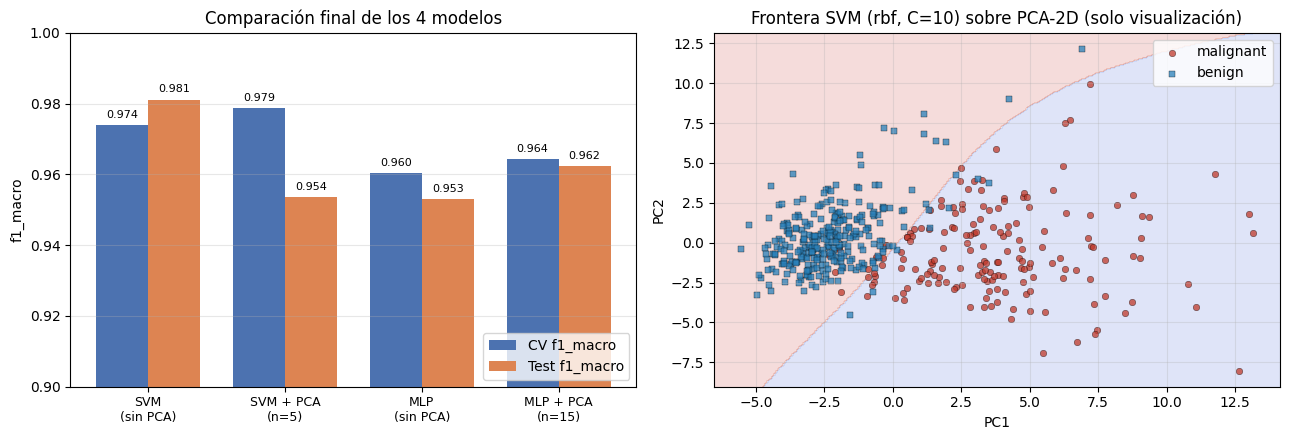

In [ ]:
# Visualización final: comparación lado a lado de los cuatro modelos en test
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
modelos = ["SVM\n(sin PCA)", f"SVM + PCA\n(n={best_n_svm})", "MLP\n(sin PCA)", f"MLP + PCA\n(n={best_n_mlp})"]
cv_scores = [
    svm_grid.best_score_,
    svm_pca_results["cv_f1_mean"].max(),
    mlp_grid.best_score_,
    mlp_pca_results["cv_f1_mean"].max(),
]
test_scores = [
    f1_svm,
    f1_score(y_test, y_pred_svm_pca, average="macro"),
    f1_mlp,
    f1_score(y_test, y_pred_mlp_pca, average="macro"),
]
x = np.arange(len(modelos))
w = 0.38
ax.bar(x - w/2, cv_scores, width=w, label="CV f1_macro", color="#4c72b0")
ax.bar(x + w/2, test_scores, width=w, label="Test f1_macro", color="#dd8452")
for i, (cv, te) in enumerate(zip(cv_scores, test_scores)):
    ax.text(i - w/2, cv + 0.002, f"{cv:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, te + 0.002, f"{te:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=9)
ax.set_ylim(0.90, 1.0)
ax.set_ylabel("f1_macro")
ax.set_title("Comparación final de los 4 modelos")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
viz_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
    ("svm", SVC(random_state=RANDOM_STATE, best_svm_params)),
]).fit(X_train, y_train)

X_train_2d = viz_pipe.named_steps["pca"].transform(
    viz_pipe.named_steps["scaler"].transform(X_train)
)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = viz_pipe.named_steps["svm"].predict(grid).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.18, cmap="coolwarm")
for cls, color, marker in [(0, "#c0392b", "o"), (1, "#2980b9", "s")]:
    mask = y_train == cls
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               c=color, label=target_names[cls], s=22, alpha=0.75, edgecolors="k", linewidths=0.3,
               marker=marker)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Frontera SVM ({best_svm_params['kernel']}, C={best_svm_params['C']}) sobre PCA-2D (solo visualización)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Conclusiones para nuestro dataset

### 7.0 ¿Cómo se ven los datos? 

-357 instancias benignas (~62.7%) y 212 malignas (~37.3%). El dataset presenta un desbalance moderado a favor de la clase benigna.
- Se aplicó StandardScaler dentro del Pipeline; cada feature quedó con media ≈ 0 y varianza ≈ 1, lo que normaliza escalas y distancias entre features.
- Muchas variables son medidas geométricas relacionadas (mean radius, mean perimeter, mean area o las versiones worst …), por lo que es esperable encontrar correlaciones altas y redundancia en las 30 features originales.
- La proyección sobre las dos primeras componentes principales muestra dos grupos bien separados con poca superposición (PC1 ≈ 44% de la varianza, PC2 ≈ 19%). Se necesitan 10 componentes para alcanzar el 95% de la varianza y 17 para el 99%; los 5 primeros ya explican el 85.14%.


1. SVM sin PCA

Que rbf con $\gamma$ pequeño se comporte casi idéntico al linear nos confirma que el problema es esencialmente lineal en el espacio estandarizado.
Las 569 muestras son casi linealmente separables en las 30 features estandarizadas. Los tumores benignos y malignos ocupan regiones bastante convexas y separadas.

Aunque RBF gana por márgenes mínimos en CV, en la práctica linear sería igual de válido y tiene la ventaja de exponer pesos $\boldsymbol{w}$ interpretables. Si la prioridad es interpretabilidad, linear es preferible; si la prioridad es la última gota de F1, rbf con $\gamma$ pequeño la consigue.

Parámetro de regularización $C$:

- En linear, los $C$ pequeños (0.01, 0.1) no tienen problema pues la base de datos es ya casi linealmente separable, así que un margen más amplio funciona bien. En rbf, en cambio, el mejor $C$ fue 10, porque para $\gamma$ tan pequeño hace falta más penalización por errores para que el modelo no infraajuste.

- Valores extremos (C=100 con gamma=1) sí provocaron sobreajuste o caídas; pero dentro del rango razonable, la SVM se comporta de forma estable.

1. MLP sin PCA. Aqui la mejor arquitectura encontrada fue hidden_layer_sizes=(64, 32) con activación tanh y alpha=1e-4 (CV F1=0.9604; test accuracy=0.9561; test F1=0.9531). Notamos que con tanh y (64, 32), distintos valores de alpha (1e-4, 1e-3, 1e-2) arrojan exactamente el mismo CV F1=0.9604.


No hace falta una red muy profunda: el segundo mejor modelo tras (64,32) es (32,16) con relu (0.9536). La arquitectura de 3 capas (64,32,16) no aportó mejora (0.9519) y aumentó la varianza entre folds (std=0.0298). Los datos tienen baja dimensionalidad intrínseca pese a 30 features.
La activación tanh fue la mejor ya que produce salidas simétricas en $[-1, 1]$, lo que facilita entrenamientos estables con solver="adam". relu quedó muy cerca; logistic fue claramente peor (0.9111).
early_stopping=True fue importante pues corta el entrenamiento cuando la validación interna deja de mejorar, evita el sobreajuste y reduce el tiempo de cómputo.

Comparación SVM vs MLP sin PCA:

En CV, SVM (0.9739) supera al MLP (0.9604). En test, la diferencia es aún más clara: SVM logra F1=0.9812 frente a 0.9531 del MLP. La SVM se equivoca solo en 2 casos del test (1 maligno y 1 benigno) mientras que el MLP se equivoca en 5.
SVM también es más rápido de entrenar y predecir, y no requiere early_stopping ni inicialización aleatoria estable.
En este dataset concreto, SVM (con kernel rbf o linear) es preferible al MLP por mejor desempeño y menor variabilidad.

1. SVM + PCA:
Aqui probamos n_components ∈ {2, 5, 10, 15, 17} manteniendo los hiperparámetros que eran los mejires (rbf, C=10, gamma=0.01). El óptimo en CV se logra con apenas 5 componentes (CV=0.9789), incluso mejor que la SVM con 30 features (0.9739). Esto indica que PCA elimina ruido y descorrelaciona las direcciones informativas para la SVM.
Sin embargo, 5 componentes recortan demasiado para el conjunto de prueba: el test F1 cae a 0.9535. Con 15-17 componentes se recupera el test F1=0.9812 que ya teníamos sin PCA, ahora usando la mitad de las features.

Con PCA podemos llegar al mismo desempeño con la mitad de dimensiones (15 vs 30) y, según la métrica que privilegiemos (CV o test), incluso menos. PC1 y PC2 explican buen porcentaje de la varianza, suficiente para dejar las clases casi separadas en 2D, pero no lo bastante como para que la SVM rinda al 100%.

1. MLP + PCA
Para el MLP la mejor configuración fue n_components=15 (CV F1=0.9644; test accuracy=0.9649; test F1=0.9623). En este caso PCA sí mejoró el test set: pasamos de F1=0.9531 (30 features) a F1=0.9623 (15 componentes), una ganancia pequeña pero consistente.

PCA actúa como regularización implícita: al descartar direcciones de baja varianza, reduce los grados de libertad efectivos del MLP. Con 15 entradas en lugar de 30, el MLP (64, 32) tiene aproximadamente la mitad de parámetros en la primera capa, lo que ayuda a generalizar.
Aun así, MLP+PCA (test F1=0.9623) sigue por detrás de SVM sin PCA (test F1=0.9812). PCA no convierte al MLP en el mejor modelo del experimento, solo lo hace más estable.
Es importante notar también que con n_components=10 el MLP cae a F1=0.8994 en test: es decir, el MLP es más sensible al número de componentes que la SVM, probablemente porque pequeños cambios en la representación afectan a la geometría de la red y al punto donde early_stopping se dispara.

Finalmente, vemos que en el dataset Breast Cancer Wisconsin el mejor modelo absoluto fue la SVM rbf con C=10, gamma=0.01 (test F1=0.9812). El kernel linear con C=0.1 queda prácticamente igualado y es la alternativa preferible si se prioriza interpretabilidad.